[Hyndman and Athanasopoulos (2013)](https://www.otexts.org/fpp/) outline the general approach for fitting an ARIMA model to a set of time series data.

1. Plot the data. Identify any unusual observations.  

2. If necessary, transform the data (e.g. [log transformations](https://en.wikipedia.org/wiki/Data_transformation_(statistics)), [power transformations](https://en.wikipedia.org/wiki/Power_transform), etc.) to stabilize the variance.  

3. If the data is non-stationary: take first differences of the data until the data are stationary.  

4. Examine the ACF/PACF: Which AR($p$), MA($q$), ARMA($p, q$) or ARIMA($p, d, q$) model is appropriate?  

5. Choose a model and then use the [$AICc$](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) as a criterion to search for a better model. 

6.  Check the residuals from the chosen model by plotting the ACF of the residuals, and doing a [*Portmanteau test*](https://en.wikipedia.org/wiki/Portmanteau_test) of the residuals. If they do not look like white noise, try a modified model.  

7. Once the residuals look like white noise, calculate forecasts.  


***


In [1]:
%load_ext lab_black

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random


#### The data

Examplarily, we will fit a model to the *global annual temperature anomalies* (`t_global`) provided by the [Berkeley Earth Surface Temperature Study](http://berkeleyearth.org/summary-of-findings/). Temperatures are given in Celsius and are reported as anomalies relative to the period January 1850 to December 2000 average. Revisit the section on *data sets used* to remind yourself how we downloaded and extracted the data set of interest.



In [3]:
t_global = pd.read_json(
    "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/t_global.json"
)
t_global["Date"] = pd.to_datetime(t_global["Date"], format="%Y-%m-%d", errors="coerce")
t_global = t_global.set_index("Date")["Monthly Anomaly_global"]

t_global

Date
1750-01-01   -0.993
1750-02-01   -1.679
1750-03-01   -0.192
1750-04-01   -0.531
1750-05-01   -1.881
              ...  
2022-05-01    1.023
2022-06-01    1.315
2022-07-01    1.289
2022-08-01    1.231
2022-09-01    1.090
Name: Monthly Anomaly_global, Length: 3273, dtype: float64

We see that the data set consist of monthly mean temperatures.

> Exercise: Aggregate the data (`t_global`) to annual means using the `groupby()` function.


In [4]:
## Your code here ...

In [5]:
temp_global_year = t_global.groupby(t_global.index.to_period("Y")).agg("mean")

Then, we split the data set into two parts. One part, the *training set*, is the period 1850 to 2000. Based on that data set we learn the model parameters. The other part, the *test set*, is the period 2001 to 2021. This part is used to validate our model, as we compare the model forecast with the observations. 

> Exercise: Subset the time series (`temp_global_year`) to the period 1850 to 2000 and to the period 2001 to 2016.



In [6]:
## Your code here...

In [7]:
temp_global_training = temp_global_year["1850-01-01":"2000-01-01"]
temp_global_test = temp_global_year["2000-01-01":]



Let us plot the data and identify any unusual observations.


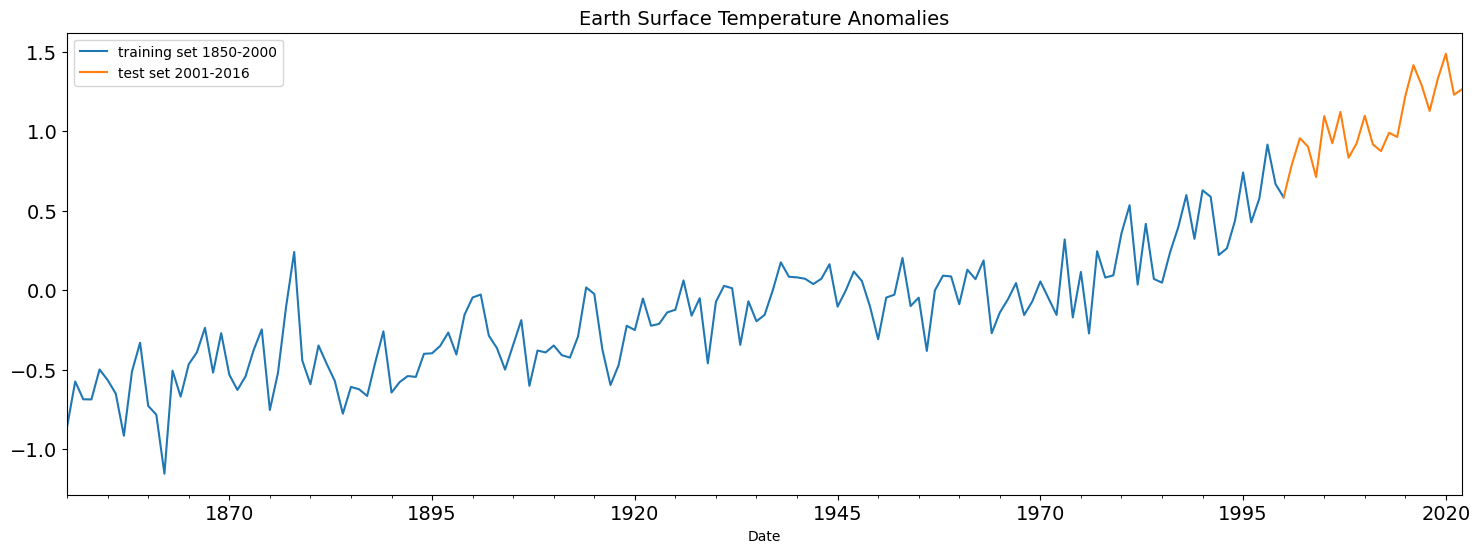

In [8]:
plt.figure(figsize=(18, 6))
plt.title("Earth Surface Temperature Anomalies", fontsize=14)
temp_global_training.plot(label="training set 1850-2000", fontsize=14)
temp_global_test.plot(label="test set 2001-2016", fontsize=14)

plt.legend()
plt.show()


It seems that there are no outliers or unusual observation in the data set. 

***
#### Data transformation

With respect to the plot above it does not seem that the variation increases or decreases with the level of the time series. Thus, probably no transformation is required. However, just as a sanity check we apply a [*Box-Cox transformation*](https://en.wikipedia.org/wiki/Power_transform) using the [`scipy.stats.boxcox`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html()) function in Python and plot the transformed data against the original data. 

The Box-Cox transformation is defined as follows:

$$
w_t =
\begin{cases}
log(y_t)  & \text{if } \lambda=0 \\
(y_t^{\lambda}-1)/\lambda & \text{otherwise}
\end{cases}
$$

The Box-Cox transformation depends on the parameter $\lambda$. So if $\lambda =0$ the natural logarithm is  used, but if $\lambda \ne0$, a power transformation is used followed by some simple scaling. We can make use of the `scipy.stats.boxcox` function, which chooses the value of $\lambda$, which minimizes the [coefficient of variation](https://en.wikipedia.org/wiki/Coefficient_of_variation) and uses that value within the transformation.


In [9]:
t_global

Date
1750-01-01   -0.993
1750-02-01   -1.679
1750-03-01   -0.192
1750-04-01   -0.531
1750-05-01   -1.881
              ...  
2022-05-01    1.023
2022-06-01    1.315
2022-07-01    1.289
2022-08-01    1.231
2022-09-01    1.090
Name: Monthly Anomaly_global, Length: 3273, dtype: float64

In [10]:
from scipy.stats import boxcox

boxcox_transformed_data, boxcox_lamba = boxcox(temp_global_training + 10)
boxcox_transformed_data = pd.Series(
    boxcox_transformed_data, index=temp_global_training.index
)

We use the given $\lambda$ and plot the transformed time series against the original time series.

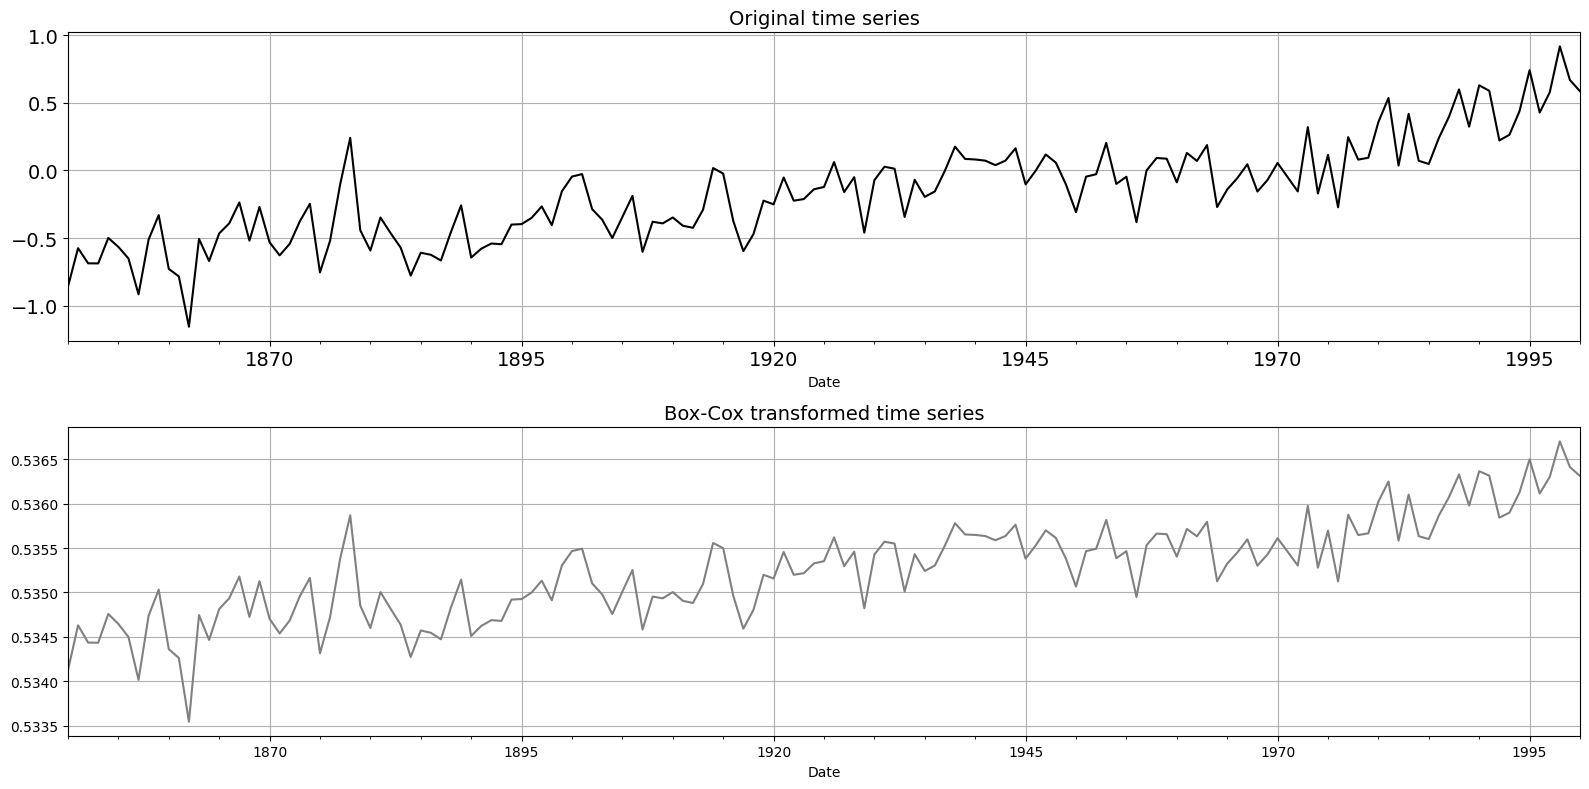

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
temp_global_training.plot(ax=ax[0], color="black", fontsize=14)
ax[0].set_title("Original time series", fontsize=14)


boxcox_transformed_data.plot(
    ax=ax[1],
    color="grey",
)
ax[1].set_title("Box-Cox transformed time series", fontsize=14)

ax[0].grid()
ax[1].grid()

plt.tight_layout()
plt.show()


The Box-Cox transformed time series (gray line) does not differ significantly from the original time series (black line). Hence, we continue our analysis with the original time series data. 


***

#### Stationary check

Fitting an ARIMA model requires the series to be stationary, which means that the *mean*, *variance*, and *autocovariance* of the series are time invariant. Based on our domain knowledge and the visualization  of the time series data we are quite sure that the temperature time series is not stationary. 

As a proof of concept we apply the [**Kwiatkowski-Phillips-Schmidt-Shin (KPSS)**](https://en.wikipedia.org/wiki/KPSS_test) test. Recall, the null hypothesis in a KPSS test is that a time series is stationary. We use the function we introduced in a previous section. 

$H_0:\text{The time series is trend-stationary.}$

$H_A:\text{The time series is not trend-stationary.}$

In [12]:
# KPSS test
from statsmodels.tsa.stattools import kpss


def kpss_test(series, **kw):
    statistic, p_value, n_lags, critical_values = kpss(series, **kw)
    # Format Output
    print(f"KPSS Statistic: {statistic}")
    print(f"p-value: {p_value}")
    print(f"num lags: {n_lags}")
    print("Critial Values:")
    for key, value in critical_values.items():
        print(f"   {key} : {value}")
    print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

In [13]:
kpss_test(temp_global_training)

KPSS Statistic: 1.613241516211716
p-value: 0.01
num lags: 8
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is not stationary


C:\Users\mceck\miniconda3\envs\rasterdata\lib\site-packages\statsmodels\tsa\stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


The *p*-value of the KPSS test on the original data set (`temp_global_training`) is $p<0.01$. Hence we reject $H_0$ in favor of $H_A$; the original time series is **not** trend-stationary.

A non-stationary series can be corrected by a simple transformation such as differencing. Recall that the difference $(\Delta y_t)$ is calculated by subtracting one period's values from the previous period's values. Let us apply the `diff()` function and compute the KPSS test for the differenced time series.

> Exercise: Difference the `temp_global_training` time series and apply a KPSS test on the differenced time series.


In [14]:
## Your code here...

In [15]:
temp_global_training_diff1 = temp_global_training.diff()

In [16]:
kpss_test(temp_global_training_diff1.dropna())  ## ignore NaN for kpss

KPSS Statistic: 0.0976339172178381
p-value: 0.1
num lags: 24
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\mceck\miniconda3\envs\rasterdata\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(



The *p*-value of the KPSS test on the differenced data set (`temp_global_training_diff1`) is $p>0.1$. Hence we would not reject $H_0$ in favor of $H_A$; the differenced time series is trend-stationary.

Let us plot the differenced data set.

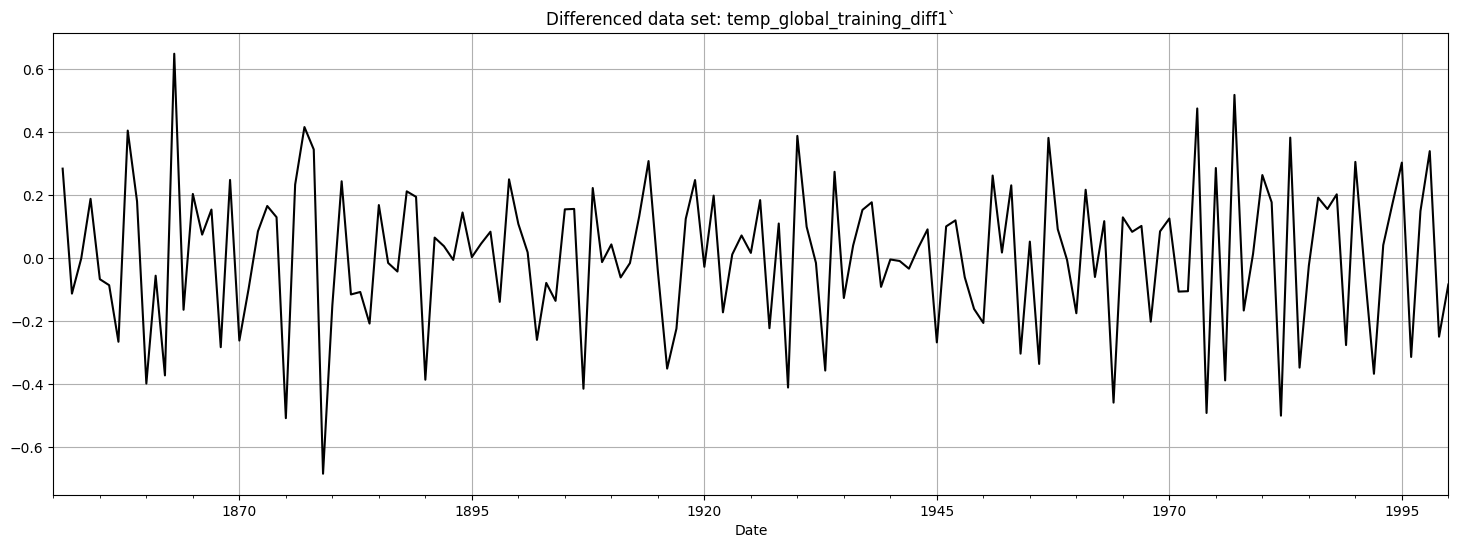

In [17]:
plt.figure(figsize=(18, 6))
plt.title("Differenced data set: temp_global_training_diff1`")
temp_global_training_diff1.plot(color="black")

plt.grid()
plt.show()



Nice, the trend is gone. Let us plot the autocorrelation function to review the correlational structure of the time series. This time we use the `plot_acf()` function from `statsmodels.graphics.tsaplots`.


<Figure size 1800x600 with 0 Axes>

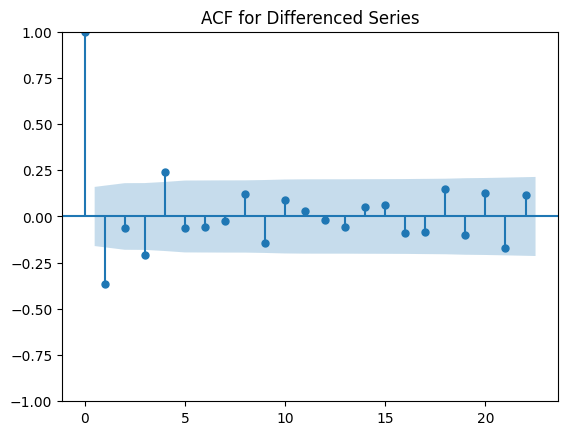

In [18]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plt.figure(figsize=(18, 6))


plot_acf(temp_global_training_diff1.dropna())
plt.title("ACF for Differenced Series")

plt.show()



The plot shows significant spikes at a lag of 1, 3 and 4 years. 


***

#### Examine the ACF/PACF

In the next step, we need to identify a time series model. We need to find out which AR($p$), MA($q$), ARMA($p, q$) or ARIMA($p, d, q$) model is appropriate for our data set.

We have seen that it is possible to distinguish between AR, MA and ARMA models by the behavior of their ACF and PACF functions. If the ACF exhibits slow decay and the PACF cuts off sharply after lag $p$, we would identify the series as AR($p$). If the PACF shows slow decay and the ACF show a sharp cutoff after lag $q$, we would identify the series as being MA($q$). If both the ACF and PACF show slow decay we would identify the series as being mixed ARMA.

The theoretical behavior of ACF and PACF for ARMA models is summarized below ([Shumway and Stoffer 2011](http://www.springer.com/gp/book/9783319524511) and [Wei 2006](http://civil.colorado.edu/~balajir/CVEN6833/lectures/wwts-book.pdf)).

$$
\begin{array}{l|lll}
 & \text{AR}(p) & \text{MA}(q) & \text{ARMA}(p,q) \\
\hline
\text{ACF} & \text{Tails off}^\text{1} & \text{Cuts off after lag }q & \text{Tails off after lag (}q-p\text{)} \\
\text{PACF} & \text{Cuts off after lag }p &  \text{Tails off}^\text{1}  & \text{Tails off after lag (}p-q\text{)}\\
\hline
\end{array}
$$
_$^\text{1}$Tails off as exponential decay or damped sine wave._


It should be noted that the sampling variation and the correlation among the sample ACF and PACF often disguise the theoretical ACF and PACF patterns. Hence, in the initial model identification it is recommendable to concentrate on the general broad features of these sample ACF and PACF. Model improvement can be easily achieved at a later stage of diagnostic checking ([Wei 2006](http://civil.colorado.edu/~balajir/CVEN6833/lectures/wwts-book.pdf)).


Let us plot the ACF and PACF and try to figure out the appropriate model configuration.



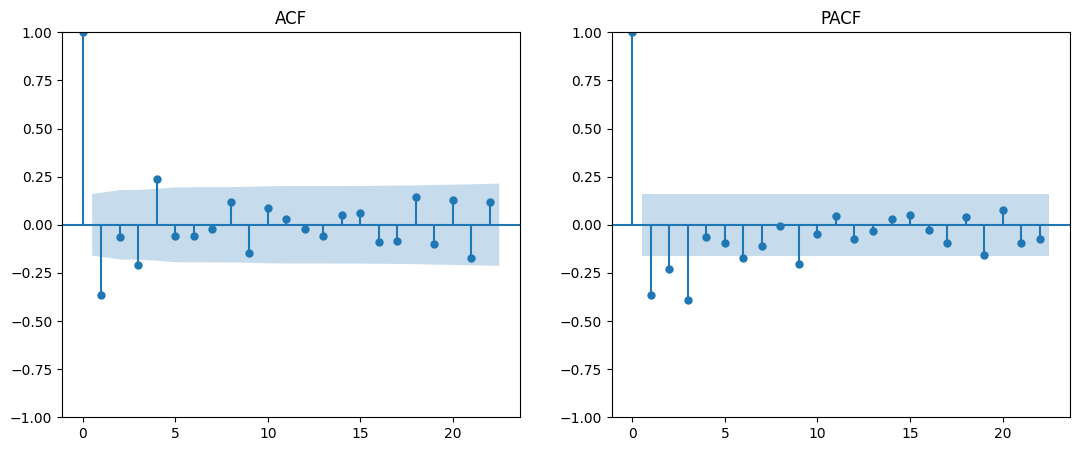

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

plot_acf(temp_global_training_diff1.dropna(), ax=ax[0])
ax[0].set_title("ACF")


plot_pacf(
    temp_global_training_diff1.dropna(), method="ywm", ax=ax[1]
)  ## add the calculation method running in the background ("ywm")

ax[1].set_title("PACF")
plt.show()


It seems that the ACF behaves like a damped sine wave and that the PACF cuts off after lag $p=3$ in ACF. This is suggesting an ARIMA(3, 1, 0) process. 


***

#### Model selection

In Python you can use the class `statsmodels.tsa.arima.model.ARIMA(endog, order, exog=None, dates=None, freq=None, missing='none')`, for time series forecasting. See the documentation of the function [here](https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima_model.ARIMA.html) for further information. 

Recall what **ARIMA** stands for: 

* **AR**: Autoregression. A model that uses the dependent relationship between an observation and some number of lagged observations.
* **I**: Integrated. The use of differencing of raw observations (e.g. subtracting an observation from an observation at the previous time step) in order to make the time series stationary.
* **MA**: Moving Average. A model that uses the dependency between an observation and a residual error from a moving average model applied to lagged observations.

The parameters of the ARIMA model:

* **p**: The number of lag observations included in the model, also called the lag order.
* **d**: The number of times that the raw observations are differenced, also called the degree of differencing.
* **q**: The size of the moving average window, also called the order of moving average.


In [20]:
from statsmodels.tsa.arima.model import ARIMA

# fit model
model = ARIMA(temp_global_training, order=(3, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

                                 SARIMAX Results                                  
Dep. Variable:     Monthly Anomaly_global   No. Observations:                  151
Model:                     ARIMA(3, 1, 0)   Log Likelihood                  32.139
Date:                    Mon, 03 Apr 2023   AIC                            -56.278
Time:                            14:43:37   BIC                            -44.235
Sample:                        12-31-1850   HQIC                           -51.385
                             - 12-31-2000                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5353      0.074     -7.225      0.000      -0.681      -0.390
ar.L2         -0.3974      0.078     -5.079      0.000      -0.551      -0.244
ar.L3         -0.385

In [21]:
## extract arima parameters:

print(
    "AR 1 =",
    round(model_fit.params["ar.L1"], 4),
    "AR 2 =",
    round(model_fit.params["ar.L2"], 4),
    "AR 3 =",
    round(model_fit.params["ar.L3"], 4),
    "sigma =",
    round(model_fit.params["sigma2"], 4),
)

model_fit.aicc

AR 1 = -0.5353 AR 2 = -0.3974 AR 3 = -0.3856 sigma = 0.038


-56.0018772466296

This is an ARIMA(3, 1, 0) model written as 

$\Delta y_t = -0.5232 y_{t-1}- 0.3836 y_{t-2} -0.3758 y_{t-3}+ w_t\text{,}$

where $w_t$ is white noise with a standard deviation of $\sqrt{ 0.0382} = 0.195$.

The corrected version of [Akaike information criterion $(AICc)$](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) of this model is 55.13. This model quality metric is useful when comparing different models. In ARIMA modelling it is good practice to check some more models and compare them by comparing the $AICc$.

> Exercise: Fit some variations of ARIMA($p$, $d$, $q$) models including ARIMA(3, 1, 1), ARIMA(3, 1, 2), ARIMA(2, 1, 2) and compare their $AICc$.


In [22]:
## Your code here...

In [23]:
model = ARIMA(temp_global_training, order=(3, 1, 0))
model_fit = model.fit()
print(f"ARIMA(3,1,0) - AICc: {round(model_fit.aicc,2)}")

model = ARIMA(temp_global_training, order=(3, 1, 1))
model_fit = model.fit()
print(f"ARIMA(3,1,1) - AICc: {round(model_fit.aicc,2)}")

model = ARIMA(temp_global_training, order=(3, 1, 2))
model_fit = model.fit()
print(f"ARIMA(3,1,2) - AICc: {round(model_fit.aicc,2)}")

model = ARIMA(temp_global_training, order=(2, 1, 2))
model_fit = model.fit()
print(f"ARIMA(2,1,2) - AICc: {round(model_fit.aicc,2)}")

ARIMA(3,1,0) - AICc: -56.0
ARIMA(3,1,1) - AICc: -55.48
ARIMA(3,1,2) - AICc: -55.84
ARIMA(2,1,2) - AICc: -53.28



Of these, the ARIMA(3, 1, 2) has the smallest $AICc$ value. That is so far our best model.

***

The [`pmdarima`](https://pypi.org/project/pmdarima/) (pyramid-arima) package includes the [`auto.arima()`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) function. The function uses a variation of the [*Hyndman and Khandakar algorithm*](https://robjhyndman.com/publications/automatic-forecasting/) which combines [unit root tests](https://en.wikipedia.org/wiki/Unit_root_test), minimization of the [AICc](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) and [maximum likelihood estimation (MLE)](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation) to obtain an optimized ARIMA model. The [`auto.arima()`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) generates a set of optimal ($p$, $d$, $q$) that optimizes model fit criteria by searching through combinations of order parameters. See the documentation of the function [here](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html).


In [24]:
from pmdarima.arima import auto_arima

auto_model = auto_arima(temp_global_training)
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  151
Model:               SARIMAX(2, 1, 3)   Log Likelihood                  40.811
Date:                Mon, 03 Apr 2023   AIC                            -67.622
Time:                        14:43:43   BIC                            -46.547
Sample:                    12-31-1850   HQIC                           -59.060
                         - 12-31-2000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0193      0.006      3.013      0.003       0.007       0.032
ar.L1         -0.6014      0.114     -5.289      0.000      -0.824      -0.379
ar.L2         -0.6555      0.110     -5.974      0.000      -0.871      -0.440
ma.L1         -0.0103      0.105     -0.098      0.922      -0.216       0.196
ma.L2          0.1291      0.093      1.390      0.165      -0.053       0.311
ma.L3         -0.7448      0.084     -8.882      0.000      -0.909      -0.580
sigma2         0.0336      0.004      7.524      0.000       0.025       0.042
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.58
Prob(Q):                              0.87   Prob(JB):                         0.75
Heteroskedasticity (H):               0.92   Skew:                            -0.02
Prob(H) (two-sided):                  0.76   Kurtosis:                         2.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The [`auto.arima()`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) function returns an ARIMA(2, 1, 3) process, with an $AICc$ of -67.085. This metric is slightly lower compared to our best model so far.


***

#### Check the residuals

Now let us check the residuals from our chosen model.

> Exercise: Plot the ACF of the residuals from the `auto_model` model.


In [25]:
## Your code here...

In [26]:
residuals = pd.DataFrame(auto_model.resid())

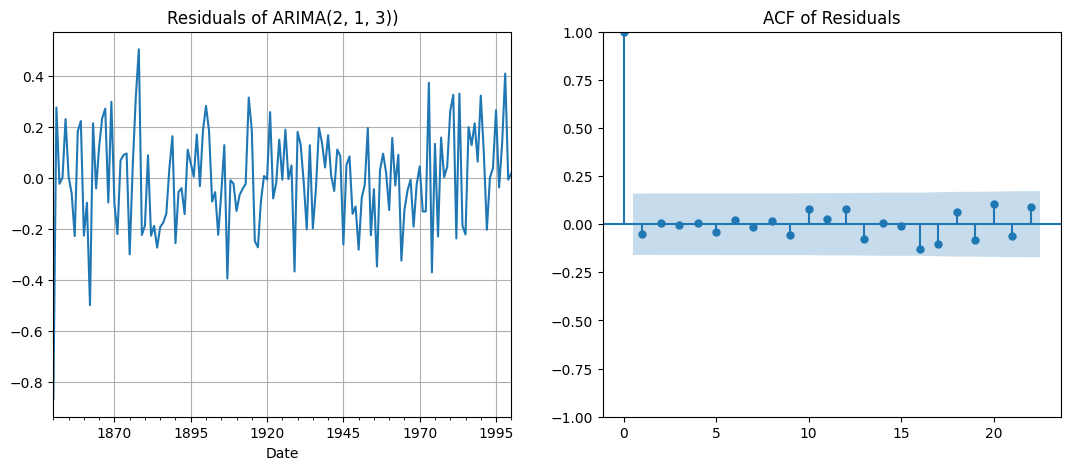

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

residuals.plot(ax=ax[0], legend=False)
ax[0].grid()
ax[0].set_title("Residuals of ARIMA(2, 1, 3))")


plot_acf(residuals, ax=ax[1])

ax[1].set_title("ACF of Residuals")
plt.show()

The ACF plot of the residuals from the ARIMA(2, 1, 3) model shows all correlations within the threshold limits (blue band) indicating that the residuals are behaving like white noise.


In addition to considering the ACF plot, where we are implicitly carrying out multiple hypothesis tests, each one with a small probability of giving a false positive, we may apply a more formal test for autocorrelation. A [*portmanteau test*](https://en.wikipedia.org/wiki/Portmanteau_test), from a French word describing a suitcase containing a number of items, tests a group of autocorrelations ([Hyndman and Athanasopoulos, 2013](https://www.otexts.org/fpp/)).

One such test is the [*Ljung-Box*](https://en.wikipedia.org/wiki/Ljung%E2%80%93Box_test) test based on the statistic 

$$Q=T(T+2)\sum_{k=1}^h(T-k)^{-1}r^2_k\text{,}$$

where $h$ is the maximum lag being considered, $T$ is number of observations, and $r_k$ is the autocorrelation for lag $k$.  If some $r_k$ values are large (positive or negative), then $Q$ will be large. If the autocorrelations did come from a white noise series, then both $Q$ would have a $\chi^2$ distribution with $(h-K)$ degrees of freedom where $K$ is the number of parameters in the model.  [Hyndman and Athanasopoulos (2013)](https://www.otexts.org/fpp/) suggest using $h=10$ for non-seasonal data and $h=2m$ for seasonal data, where $m$ is the period of seasonality. See the documentation of the function in Python [here](https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).



**Ljung-Box test**

$H_0: \text{The data is independently distributed.}$

$H_A: \text{The data is not independently distributed, it exhibits serial correlation.}$


In [28]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# perform Ljung-Box test on residuals with lag=10
Btest = acorr_ljungbox(
    auto_model.resid(), lags=[10], return_df=True, model_df=5
)  ## ARIMA model_df = lags - df , df =  p +q

In [29]:
Btest

,lb_stat,lb_pvalue
10,2.366672,0.796427


The portmanteau test returns a large p-value (P = 0.7565), suggesting the residuals are white noise. 


***

#### Calculate forecasts

Forecasting using a fitted model is straightforward in Python. We use the [`forecast()`](https://www.statsmodels.org/v0.11.1/generated/statsmodels.tsa.arima_model.ARMAResults.forecast.html) function from the [`statsmodels`](https://www.statsmodels.org/stable/index.html) package. We specify forecast horizon in `steps`, the number of out of sample forecasts from the end of the sample and use the fitted model to generate those predictions. In addition we specify `alpha`, the confidence intervals for the forecasts (1 - `alpha` %).


In [30]:
model = ARIMA(temp_global_training, order=(2, 1, 3))
fitted = model.fit()

In [31]:
forecast_series = fitted.forecast(40, alpha=0.05)

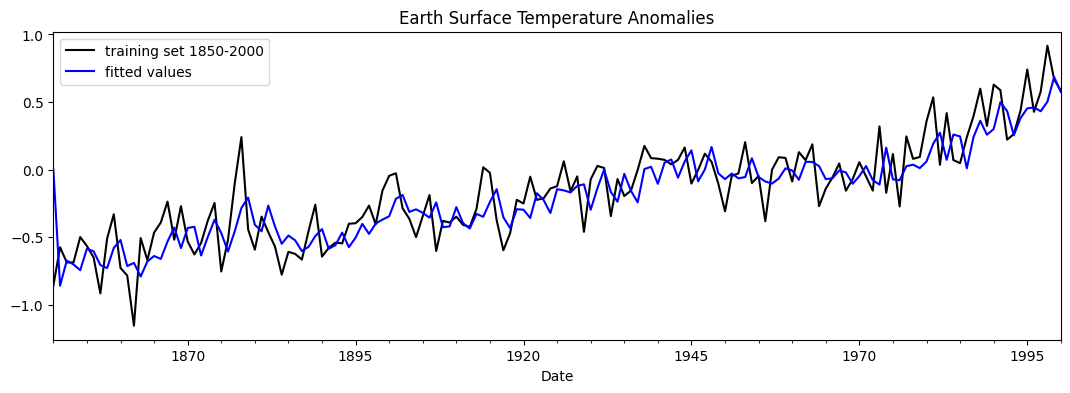

In [32]:
plt.figure(figsize=(13, 4))
plt.title("Earth Surface Temperature Anomalies")
temp_global_training.plot(color="black", label="training set 1850-2000")
plt.plot(fitted.fittedvalues, color="blue", label="fitted values")

plt.legend()
plt.show()

Now, we can see how the model compares to the original time series.

In [33]:
forecast = fitted.get_forecast(40)
conf_int_95 = forecast.conf_int(alpha=0.05)  # 95% conf
conf_int_80 = forecast.conf_int(alpha=0.2)  # 80% conf

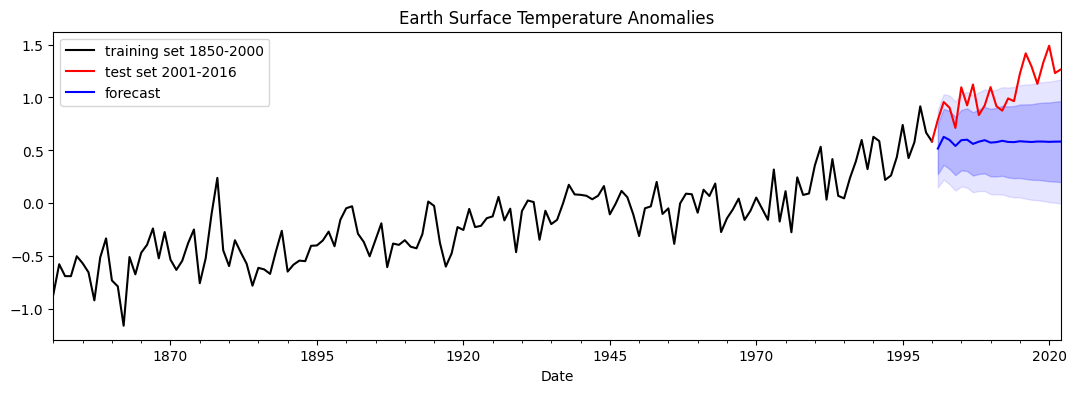

In [34]:
plt.figure(figsize=(13, 4))
plt.title("Earth Surface Temperature Anomalies")
temp_global_training.plot(color="black", label="training set 1850-2000")
temp_global_test.plot(color="red", label="test set 2001-2016")
plt.plot(forecast_series, label="forecast", color="blue")


plt.fill_between(
    conf_int_95.index,
    conf_int_95["lower Monthly Anomaly_global"],
    conf_int_95["upper Monthly Anomaly_global"],
    color="b",
    alpha=0.1,
)

plt.fill_between(
    conf_int_80.index,
    conf_int_80["lower Monthly Anomaly_global"],
    conf_int_80["upper Monthly Anomaly_global"],
    color="b",
    alpha=0.2,
)


plt.legend()
plt.show()


Forecast estimates are provided with confidence bounds: 80% confidence limits shaded in darker blue, and 95% in lighter blue. 



In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))